In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# filter out warning
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/root/workspace/vllm/examples/logs/4gpu'
BASELINE_DATA_PATH = '/root/workspace/vllm-spec/vllm/examples/logs/4gpu'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']

In [3]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_itl, p99_itl = [], [], [], [], [], []
    for store_cache_layer in store_cache_layers:
        filename = f'{DATA_PATH}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_swap_{store_cache_layer}_4gpu.log'
        with open(filename, 'r') as f:
            lines = f.readlines()
            output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_itl_, p99_itl_ = [], [], [], [], [], []
            for line in lines:
                if 'Output token throughput' in line:
                    output_tokens_tgt.append(float(line.split()[-1]))
                if 'Request throughput' in line:
                    reqs_tgt.append(float(line.split()[-1]))
                if 'Mean TPOT' in line:
                    mean_tpot_.append(float(line.split()[-1]))
                if 'P99 TPOT' in line:
                    p99_tpot_.append(float(line.split()[-1]))
                if 'Mean ITL' in line:
                    mean_itl_.append(float(line.split()[-1]))
                if 'P99 ITL' in line:
                    p99_itl_.append(float(line.split()[-1]))    

        output_tokens.append(np.mean(output_tokens_tgt))
        reqs.append(np.mean(reqs_tgt))
        mean_tpot.append(np.mean(mean_tpot_))
        p99_tpot.append(np.mean(p99_tpot_))
        mean_itl.append(np.mean(mean_itl_))
        p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_itl, p99_itl            

In [4]:
def get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy):
    if baseline_policy == 'full_mem':
        filename = f'{BASELINE_DATA_PATH}/{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_1.0_4gpu.log'
    else:    
        filename = f'{BASELINE_DATA_PATH}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_{baseline_policy}_1.0_4gpu.log'
    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_itl, p99_itl = [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean ITL' in line:
                mean_itl.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl.append(float(line.split()[-1]))    
        
    return np.mean(output_tokens_tgt), np.mean(reqs_tgt), np.mean(mean_tpot_), np.mean(p99_tpot_), np.mean(mean_itl), np.mean(p99_itl)         

In [5]:
# plot throughput
def plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_itl, baseline_p99_itl = get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [abs(mean_tpot[i]-baseline_mean_tpot) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [abs(p99_tpot[i]-baseline_p99_tpot) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_itl_imp = [abs(mean_itl[i]-baseline_mean_itl) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [abs(p99_itl[i]-baseline_p99_itl) / baseline_p99_itl *100 for i in range(len(p99_itl))]
    
    # print(f'reqs_imp: max:{float(max(reqs_imp)):.2f}%, mean:{float(np.mean(reqs_imp)):.2f}%, min:{float(min(reqs_imp)):.2f}%')
    # print(f'output_tokens_imp: max:{float(max(output_tokens_imp)):.2f}%, mean:{float(np.mean(output_tokens_imp)):.2f}%, min:{float(min(output_tokens_imp)):.2f}%')
    # print(f'mean_tpot_imp: max:{float(max(mean_tpot_imp)):.2f}%, mean:{float(np.mean(mean_tpot_imp)):.2f}%, min:{float(min(mean_tpot_imp)):.2f}%')
    # print(f'p99_tpot_imp: max:{float(max(p99_tpot_imp)):.2f}%, mean:{float(np.mean(p99_tpot_imp)):.2f}%, min:{float(min(p99_tpot_imp)):.2f}%')
    # print(f'mean_itl_imp: max:{float(max(mean_itl_imp)):.2f}%, mean:{float(np.mean(mean_itl_imp)):.2f}%, min:{float(min(mean_itl_imp)):.2f}%')
    # print(f'p99_itl_imp: max:{float(max(p99_itl_imp)):.2f}%, mean:{float(np.mean(p99_itl_imp)):.2f}%, min:{float(min(p99_itl_imp)):.2f}%')

    # fig = plt.figure(figsize=(3, 2), dpi=120)
    # ax = fig.add_subplot(111)
    # ax.plot(store_cache_layers, output_tokens_imp, label='out_toks', linestyle=linestyles[0], marker=markers[0], color=plt.cm.tab20(0/5), markersize=5)
    # ax.plot(store_cache_layers, reqs_imp, label='reqs', linestyle=linestyles[1], marker=markers[1], color=plt.cm.tab20(1/5), markersize=5)
    # ax.plot(store_cache_layers, mean_tpot_imp, label='avg_tpot', linestyle=linestyles[2], marker=markers[2], color=plt.cm.tab20(2/5), markersize=5)
    # ax.plot(store_cache_layers, p99_tpot_imp, label='p99_tpot', linestyle=linestyles[3], marker=markers[3], color=plt.cm.tab20(3/5), markersize=5)
    # ax.plot(store_cache_layers, mean_itl_imp, label='avg_itl', linestyle=linestyles[0], marker=markers[4], color=plt.cm.tab20(4/5), markersize=5)
    # ax.plot(store_cache_layers, p99_itl_imp, label='p99_itl', linestyle=linestyles[1], marker=markers[5], color=plt.cm.tab20(5/5), markersize=5)
    # ax.set_xlabel('Store cache layers(%)')
    # ax.set_ylabel('Improvement(%)')
    # ax.spines['right'].set_visible(False)
    # ax.spines['top'].set_visible(False)
    # ax.grid(linestyle='-.', alpha=0.3)
    # ax.set_ylim(min(min(output_tokens_imp), min(reqs_imp), min(mean_tpot_imp), min(p99_tpot_imp), min(mean_itl_imp), min(p99_itl_imp))*1.4, max(max(output_tokens_imp), max(reqs_imp), max(mean_tpot_imp), max(p99_tpot_imp), max(mean_itl_imp), max(p99_itl_imp))*1.4)
    # ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
    # ax.yaxis.set_major_locator(plt.MultipleLocator(30))
    # # x轴标签显示数字乘以100
    # ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
    # ax.legend( bbox_to_anchor=(-0.04, 1.05), loc='upper left', ncol=3, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5) 
    # name = model_name.split('_')[-1]
    # name = name.replace('-hf', '')
    # name = name.replace('-2', '2')
    # plt.title(f'{name}_reqs_{req_rate}_total_{total_reqs}')
    # plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    # plt.show()

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_itl_imp, p99_itl_imp
    

In [6]:
# 绘制一张大图，将不同req_rate的结果放在一张图上, 6个指标, 这张大图包含6个子图，legend放在右上角
def plot_big_fig(baseline_policy, store_cache_layers, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(15, 2), dpi=120)
    axes = [fig.add_subplot(1, 6, i+1) for i in range(6)]
    for i, ax in enumerate(axes):
        ax.plot(store_cache_layers, mean_output_tokens_imps[i], label='out_toks', linestyle=linestyles[0], marker=markers[0], color=plt.cm.tab20(0/5), markersize=5)
        ax.plot(store_cache_layers, mean_reqs_imps[i], label='reqs', linestyle=linestyles[1], marker=markers[1], color=plt.cm.tab20(1/5), markersize=5)
        ax.plot(store_cache_layers, mean_mean_tpot_imps[i], label='avg_tpot', linestyle=linestyles[2], marker=markers[2], color=plt.cm.tab20(2/5), markersize=5)
        ax.plot(store_cache_layers, mean_p99_tpot_imps[i], label='p99_tpot', linestyle=linestyles[3], marker=markers[3], color=plt.cm.tab20(3/5), markersize=5)
        ax.plot(store_cache_layers, mean_mean_itl_imps[i], label='avg_itl', linestyle=linestyles[0], marker=markers[4], color=plt.cm.tab20(4/5), markersize=5)
        ax.plot(store_cache_layers, mean_p99_itl_imps[i], label='p99_itl', linestyle=linestyles[1], marker=markers[5], color=plt.cm.tab20(5/5), markersize=5)
        ax.set_xlabel('Cache layers(%)')
        if i == 0 : ax.set_ylabel('Improvement(%)')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(linestyle='-.', alpha=0.3)
        # 除了第一个子图，其他子图的y轴不显示
        # if i != 0: ax.set_yticklabels([])
        ax.set_ylim(min(min(mean_output_tokens_imps[i]), min(mean_reqs_imps[i]), min(mean_mean_tpot_imps[i]), min(mean_p99_tpot_imps[i]), min(mean_mean_itl_imps[i]), min(mean_p99_itl_imps[i]))*1.4, max(max(mean_output_tokens_imps[i]), max(mean_reqs_imps[i]), max(mean_mean_tpot_imps[i]), max(mean_p99_tpot_imps[i]), max(mean_mean_itl_imps[i]), max(mean_p99_itl_imps[i]))*1.4)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
        # ax.yaxis.set_major_locator(plt.MultipleLocator(20))
        # ax.set_ylim(-10, 80)
        # x轴标签显示数字乘以100
        ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
        name = model_name.split('_')[-1]
        ax.set_title(f'{req_rates[i]} reqs/s')
    # legend 放在右上角
    axes[-1].legend( bbox_to_anchor=(1.4, 1.0), loc='upper right', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()

In [7]:
def plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.plot(req_rates, mean_output_tokens_imps, label='out_toks', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/5), markersize=5)
    ax.plot(req_rates, mean_reqs_imps, label='reqs', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/5), markersize=5)
    ax.plot(req_rates, mean_mean_tpot_imps, label='avg_tpot', linestyle=linestyles[2], marker=markers[2], color=plt.cm.Dark2(2/5), markersize=5)
    ax.plot(req_rates, mean_p99_tpot_imps, label='p99_tpot', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/5), markersize=5)
    ax.plot(req_rates, mean_mean_itl_imps, label='avg_itl', linestyle=linestyles[0], marker=markers[4], color=plt.cm.Dark2(4/5), markersize=5)
    ax.plot(req_rates, mean_p99_itl_imps, label='p99_itl', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/5), markersize=5)
    ax.set_xlabel('Req rates(reqs/s)')
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='-.', alpha=0.3)
    ax.xaxis.set_major_locator(plt.MultipleLocator(50))
    # ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    ax.set_ylim(min(min(mean_output_tokens_imps), min(mean_reqs_imps), min(mean_mean_tpot_imps), min(mean_p99_tpot_imps), min(mean_mean_itl_imps), min(mean_p99_itl_imps))*1.2, max(max(mean_output_tokens_imps), max(mean_reqs_imps), max(mean_mean_tpot_imps), max(mean_p99_tpot_imps), max(mean_mean_itl_imps), max(mean_p99_itl_imps))*1.4)
    ax.legend( bbox_to_anchor=(-0.04, 1.05), loc='upper left', ncol=3, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()

baseline_policy---------------------->: swap
mean_output_tokens_imps: [[1.0660624677748536, -5.350645955425812, -2.689846989535447, 2.257757637814711, -0.04284583487650365, 3.117579137709423, -0.5998416882711336, 0.3144448559581075, 0.500352207286704], [-1.133894047585459, -5.222827467472018, -4.85309474753748, -2.7814625610341275, -1.8493691964664056, -2.4545360465882333, -0.776156473145002, -0.5033257128879841, -1.0367568889767], [-0.35096945308213157, -4.94672580940188, -4.405600268276326, 0.3063837570879832, -2.0781888299494167, 2.7171552039509637, 1.853545515517321, 1.7916209377476966, -0.5453173586976447], [-1.1645943284795581, -3.492241497247485, -3.556791315255526, 0.7189115551881775, -0.759953678279862, 1.4154715316034154, 3.1342308648326793, 1.7632698047512485, 0.8287425888137977], [-0.4676863416812022, -7.230074473445737, -4.318770105627004, 0.3341437852895936, -0.43798892957116675, 3.1486920684918, 0.9165962550605277, -1.090374014956011, 1.8458378597937246], [0.479682337255

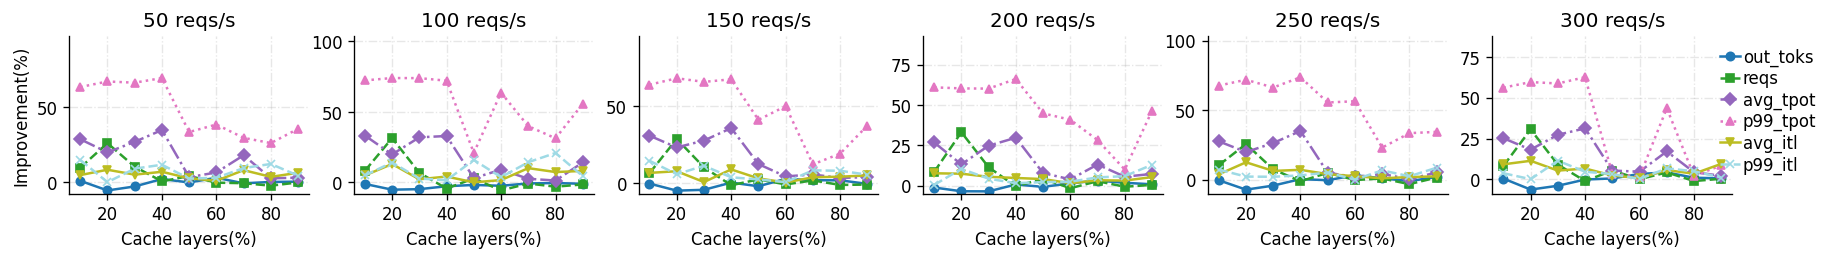

mean_output_tokens_imps: [-0.15855379572945527, -2.2901581268548235, -0.6286773672337149, -0.12366160823034583, -0.8110693218494973, -0.013794154713536535]


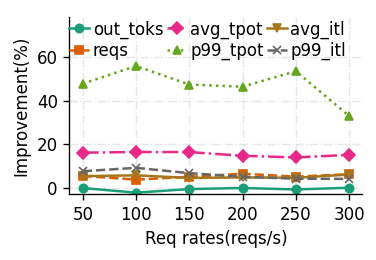

mean_output_tokens_imps: -0.6709857291018957, mean_reqs_imps: 5.304089584612332, mean_mean_tpot_imps: 15.420738783073196, mean_p99_tpot_imps: 47.35901389339684, mean_mean_itl_imps: 5.130755452986044, mean_p99_itl_imps: 6.088640085365597
mean_p99_tpot_imps: [47.80822397495441, 55.9595883038763, 47.42674564040894, 46.40160972625146, 53.56447492682455, 32.993440788065364]
baseline_policy---------------------->: recompute
mean_output_tokens_imps: [[7.644174246643147, 0.8098199368850781, 3.6438029824886997, 8.913433574655016, 6.463090155312166, 9.829218488954886, 5.869840975187169, 6.843635913619189, 7.04164346265701], [7.9566992834578905, 3.4917944371677097, 3.8955235380229554, 6.157639263425539, 7.175437244780001, 6.514626191026508, 8.347330302796818, 8.645247451010592, 8.062768061227118], [6.180622173495962, 1.2836325430542155, 1.8602266786452115, 6.881062232576561, 4.3401905399986624, 9.449850014465602, 8.529634197716952, 8.463650713890544, 5.973535547333001], [4.39353003729541, 1.93498

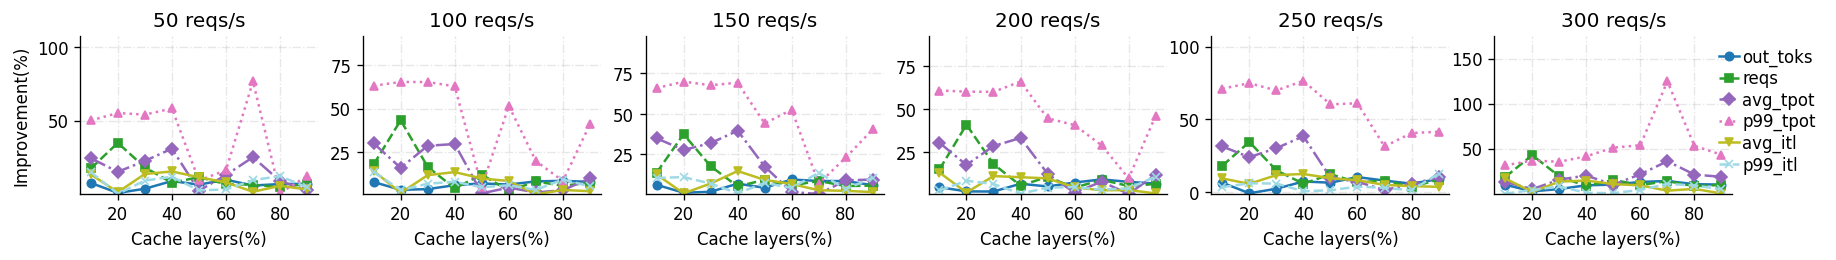

mean_output_tokens_imps: [6.339851081822484, 6.694118419212792, 5.884711626797412, 5.493000823698548, 6.181347480879843, 9.431673457495046]


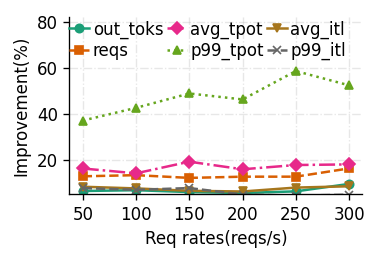

mean_output_tokens_imps: 6.670783814984354, mean_reqs_imps: 13.240734924986304, mean_mean_tpot_imps: 16.794475355524632, mean_p99_tpot_imps: 47.64423986325045, mean_mean_itl_imps: 7.412312115924728, mean_p99_itl_imps: 5.991541450747227
mean_p99_tpot_imps: [37.05496221976263, 42.603799102712934, 48.87316095206464, 46.26293682203982, 58.65056178901867, 52.42001829390402]


In [8]:
model_name = 'meta-llama/Llama-2-70b-hf'
model_name = model_name.replace('/', '_')
gpu_utilization = 0.45
req_rates = [50, 100, 150, 200, 250, 300]
total_reqs = 300
store_cache_layers = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
baseline_policies = ['swap', 'recompute']
swap_imps, recompute_imps = [], []
for baseline_policy in baseline_policies:
    print(f'baseline_policy---------------------->: {baseline_policy}')
    mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_itl_imps, mean_p99_itl_imps = [], [], [], [], [], []
    output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_itl_imps_all, p99_itl_imps_all = [], [], [], [], [], []
    for req_rate in req_rates:
        output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_itl_imps, p99_itl_imps = plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy)
        mean_output_tokens_imps.append(np.mean(output_tokens_imps))
        mean_reqs_imps.append(np.mean(reqs_imps))
        mean_mean_tpot_imps.append(np.mean(mean_tpot_imps))
        mean_p99_tpot_imps.append(np.mean(p99_tpot_imps))
        mean_mean_itl_imps.append(np.mean(mean_itl_imps))
        mean_p99_itl_imps.append(np.mean(p99_itl_imps))

        output_tokens_imps_all.append(output_tokens_imps)
        reqs_imps_all.append(reqs_imps)
        mean_tpot_imps_all.append(mean_tpot_imps)
        p99_tpot_imps_all.append(p99_tpot_imps)
        mean_itl_imps_all.append(mean_itl_imps)
        p99_itl_imps_all.append(p99_itl_imps)

    plot_big_fig(baseline_policy, store_cache_layers, output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_itl_imps_all, p99_itl_imps_all)
    plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_itl_imps, mean_p99_itl_imps)
        
    print(f'mean_output_tokens_imps: {np.mean(mean_output_tokens_imps)}, mean_reqs_imps: {np.mean(mean_reqs_imps)}, mean_mean_tpot_imps: {np.mean(mean_mean_tpot_imps)}, mean_p99_tpot_imps: {np.mean(mean_p99_tpot_imps)}, mean_mean_itl_imps: {np.mean(mean_mean_itl_imps)}, mean_p99_itl_imps: {np.mean(mean_p99_itl_imps)}')  
    print(f'mean_p99_tpot_imps: {mean_p99_tpot_imps}')
    base_imps = []
    base_imps.append(np.mean(mean_output_tokens_imps))
    base_imps.append(np.mean(mean_reqs_imps))
    base_imps.append(np.mean(mean_mean_tpot_imps))
    base_imps.append(np.mean(mean_p99_tpot_imps))
    base_imps.append(np.mean(mean_mean_itl_imps))
    base_imps.append(np.mean(mean_p99_itl_imps))
    if baseline_policy == 'swap':
        swap_imps = base_imps
    if baseline_policy == 'recompute':
        recompute_imps = base_imps  

swap_imps: [-0.6709857291018957, 5.304089584612332, 15.420738783073196, 47.35901389339684, 5.130755452986044, 6.088640085365597], recompute_imps: [6.670783814984354, 13.240734924986304, 16.794475355524632, 47.64423986325045, 7.412312115924728, 5.991541450747227]


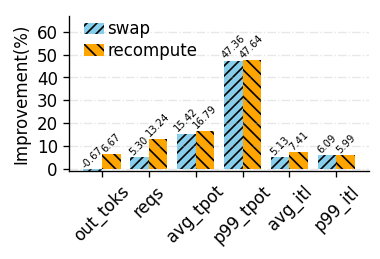

In [9]:
# 绘制柱状图，对比swap和recompute的性能提升
print(f'swap_imps: {swap_imps}, recompute_imps: {recompute_imps}')
fig = plt.figure(figsize=(3, 2), dpi=120)
ax = fig.add_subplot(111)
bar_width = 0.4
bar1 = ax.bar(np.arange(6), swap_imps, bar_width, label='swap', color='skyblue', hatch=hatches[0])
bar2 = ax.bar(np.arange(6)+bar_width, recompute_imps, bar_width, label='recompute', color='orange', hatch=hatches[1])
# 将数值标注在柱状图上
for x, y in zip(np.arange(6), swap_imps):
    ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=45, fontsize=6)
for x, y in zip(np.arange(6)+0.4, recompute_imps):
    ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=45, fontsize=6)
ax.set_xticks(np.arange(6)+0.2)
ax.set_xticklabels(['out_toks', 'reqs', 'avg_tpot', 'p99_tpot', 'avg_itl', 'p99_itl'], rotation=45)
ax.set_ylabel('Improvement(%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.set_ylim(min(min(swap_imps), min(recompute_imps)), max(max(swap_imps), max(recompute_imps))*1.4)
ax.grid(linestyle='-.', alpha=0.3, axis='y')
ax.legend( bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
plt.show()    